In [ ]:
from anomalib.data import Folder
from anomalib.models import Padim, Patchcore
from anomalib.engine import Engine
from anomalib import TaskType
import anomalib.models.components.sampling.k_center_greedy as k_center
from tqdm.notebook import tqdm
k_center.tqdm = tqdm
import torch
from torchvision.transforms.v2 import Resize
torch.set_float32_matmul_precision('medium')
# When initializing the Engine, replace the default progress bar
from lightning.pytorch.callbacks import TQDMProgressBar

In [ ]:
IMAGE_SIZE = (256, 256)
TASK = TaskType.CLASSIFICATION

In [ ]:
def train_socket_inspector():
    transform = Resize(IMAGE_SIZE, antialias=True)

    """ model = Patchcore(
        backbone="resnet18",  # Better feature extraction
        layers=["layer2", "layer3"],  # Multi-scale features
    )
    
    # More training configs
    datamodule = Folder(
        name="socket_pins",
        root="./datasets/socket_pins", 
        normal_dir="train/good",
        train_batch_size=8,  
        eval_batch_size=8,
    ) """

    model = Padim(backbone="resnet18")
    datamodule = Folder(
        name="socket_pins",
        root="./datasets/socket_pins", 
        normal_dir="train/good",
    ) 
    
    # 3. Training Engine
    # AUROC score to judge accuracy
    engine = Engine(callbacks=[TQDMProgressBar()])
    
    # 4. Fit the model
    print("Starting training...")
    engine.fit(datamodule=datamodule, model=model)
    engine.test(datamodule=datamodule, model=model)
    print("Training complete. Model saved.")

    engine.export(
        model=model,
        export_type="torch", # or "openvino" for Intel optimization
        ckpt_path="results/Padim/socket_pins/latest/weights/lightning/model.ckpt",
    )
    print("Model exported to .pt format successfully.")

if __name__ == "__main__":
    train_socket_inspector()

In [1]:
from anomalib.deploy import TorchInferencer, OpenVINOInferencer
import cv2
import matplotlib.pyplot as plt
import dotenv
import os
dotenv.load_dotenv()

True

TorchInferencer is a legacy inferencer. Consider using Engine.predict() instead, which provides a more modern and feature-rich interface for model inference.
TRUST_REMOTE_CODE is set to True. Loading model using pickle module, which is inherently insecure and can lead to arbitrary code execution. Only set this to True if you TRUST the source of the checkpoint.


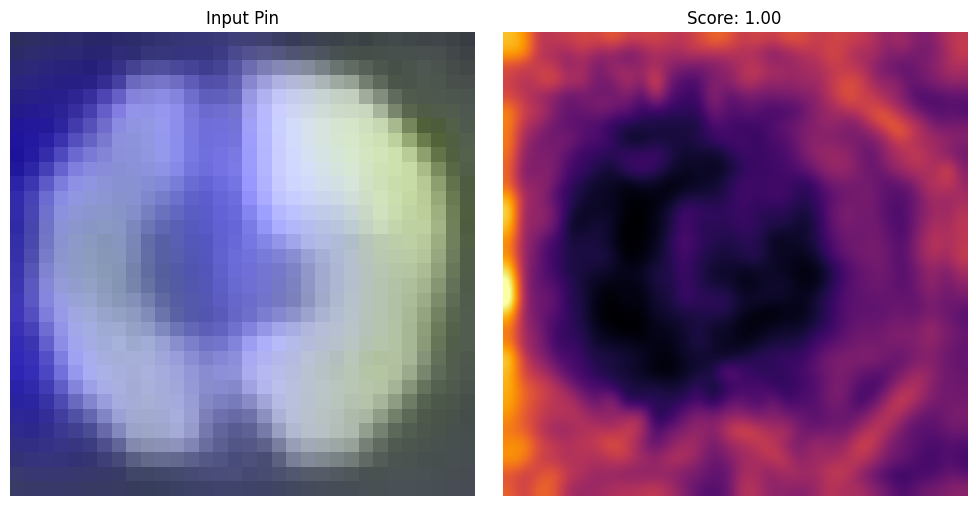

TorchInferencer is a legacy inferencer. Consider using Engine.predict() instead, which provides a more modern and feature-rich interface for model inference.
TRUST_REMOTE_CODE is set to True. Loading model using pickle module, which is inherently insecure and can lead to arbitrary code execution. Only set this to True if you TRUST the source of the checkpoint.


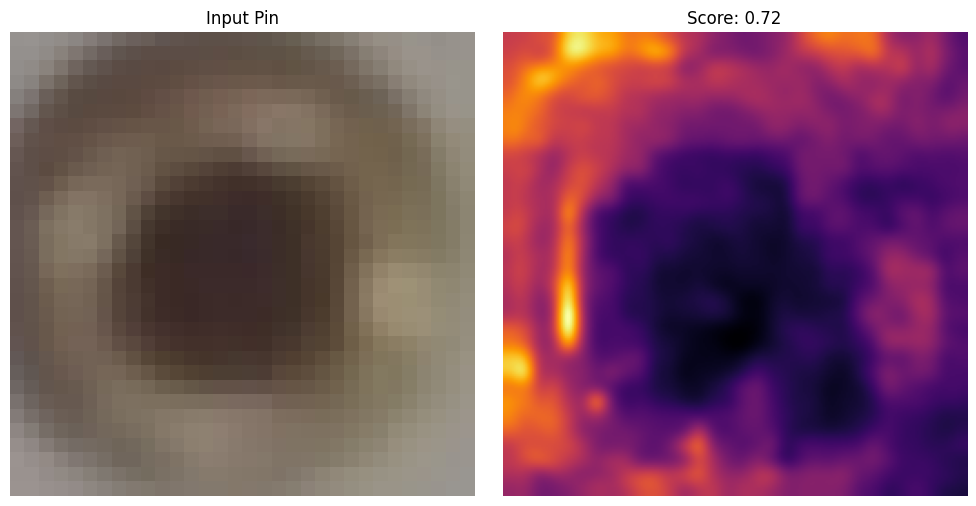

TorchInferencer is a legacy inferencer. Consider using Engine.predict() instead, which provides a more modern and feature-rich interface for model inference.
TRUST_REMOTE_CODE is set to True. Loading model using pickle module, which is inherently insecure and can lead to arbitrary code execution. Only set this to True if you TRUST the source of the checkpoint.


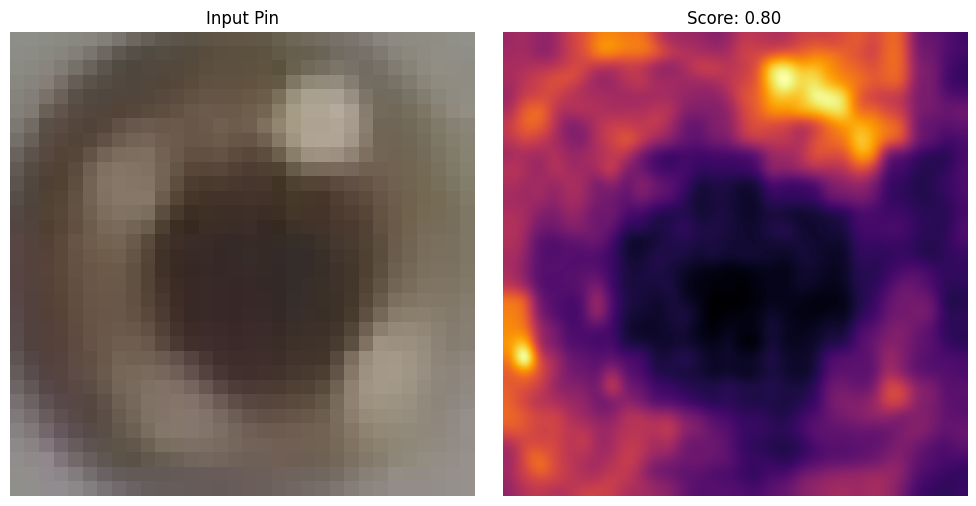

TorchInferencer is a legacy inferencer. Consider using Engine.predict() instead, which provides a more modern and feature-rich interface for model inference.
TRUST_REMOTE_CODE is set to True. Loading model using pickle module, which is inherently insecure and can lead to arbitrary code execution. Only set this to True if you TRUST the source of the checkpoint.


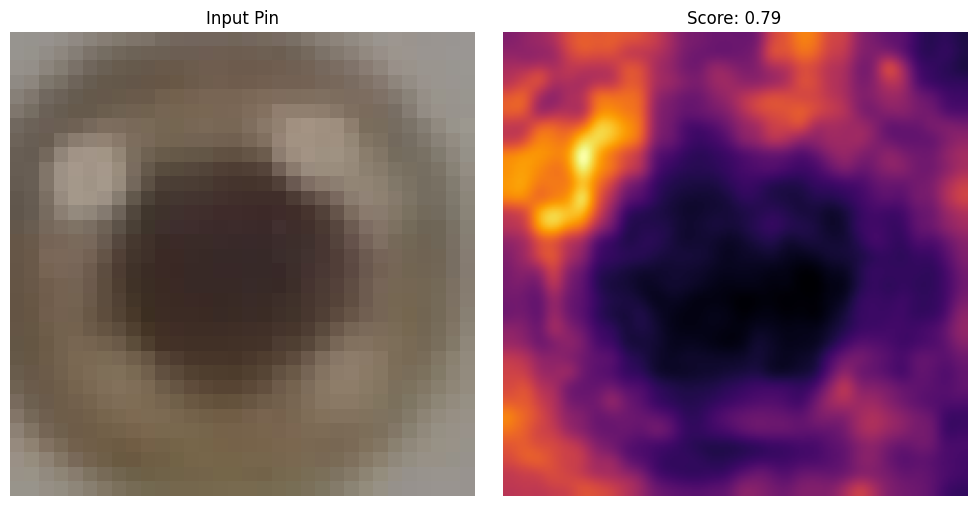

TorchInferencer is a legacy inferencer. Consider using Engine.predict() instead, which provides a more modern and feature-rich interface for model inference.
TRUST_REMOTE_CODE is set to True. Loading model using pickle module, which is inherently insecure and can lead to arbitrary code execution. Only set this to True if you TRUST the source of the checkpoint.


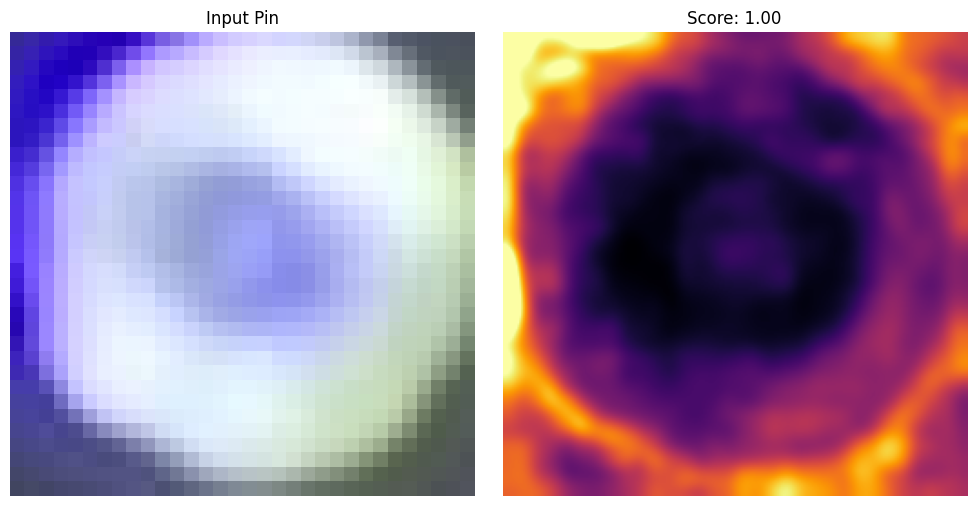

TorchInferencer is a legacy inferencer. Consider using Engine.predict() instead, which provides a more modern and feature-rich interface for model inference.
TRUST_REMOTE_CODE is set to True. Loading model using pickle module, which is inherently insecure and can lead to arbitrary code execution. Only set this to True if you TRUST the source of the checkpoint.


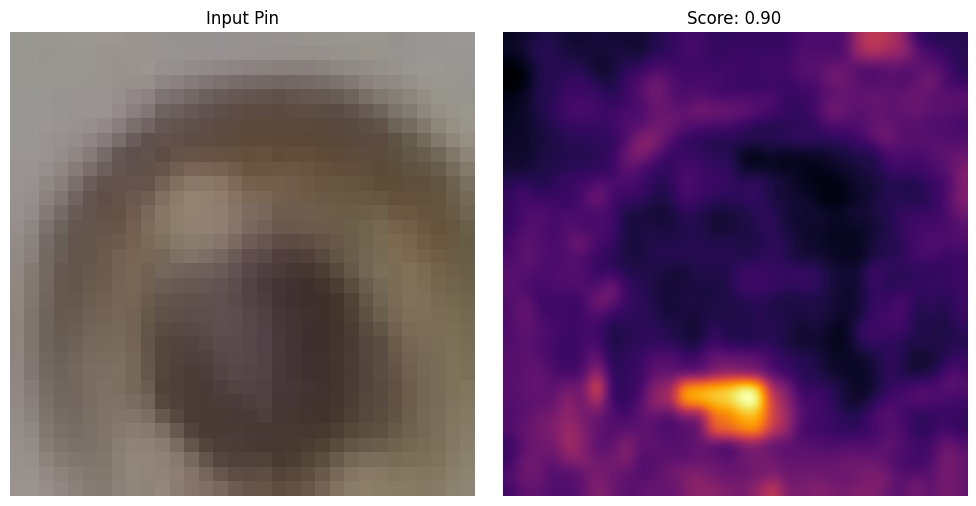

TorchInferencer is a legacy inferencer. Consider using Engine.predict() instead, which provides a more modern and feature-rich interface for model inference.
TRUST_REMOTE_CODE is set to True. Loading model using pickle module, which is inherently insecure and can lead to arbitrary code execution. Only set this to True if you TRUST the source of the checkpoint.


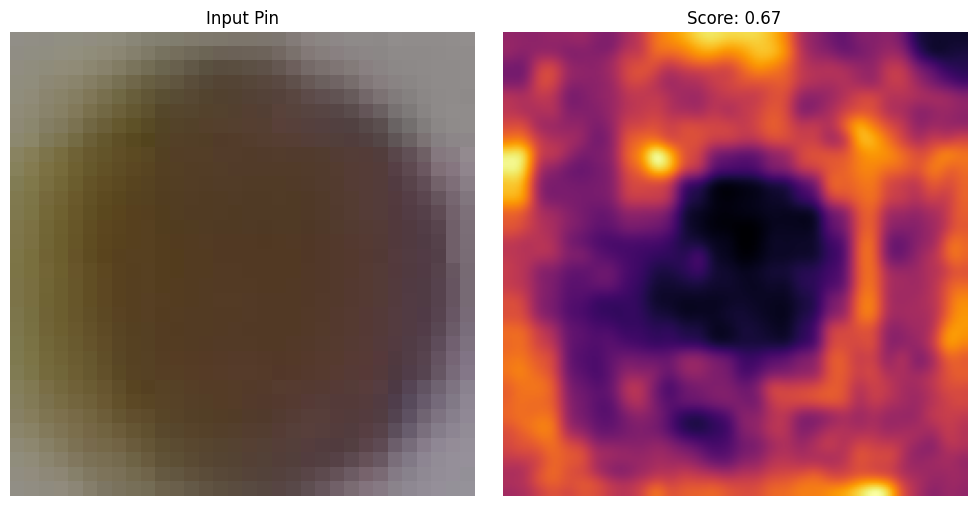

TorchInferencer is a legacy inferencer. Consider using Engine.predict() instead, which provides a more modern and feature-rich interface for model inference.
TRUST_REMOTE_CODE is set to True. Loading model using pickle module, which is inherently insecure and can lead to arbitrary code execution. Only set this to True if you TRUST the source of the checkpoint.


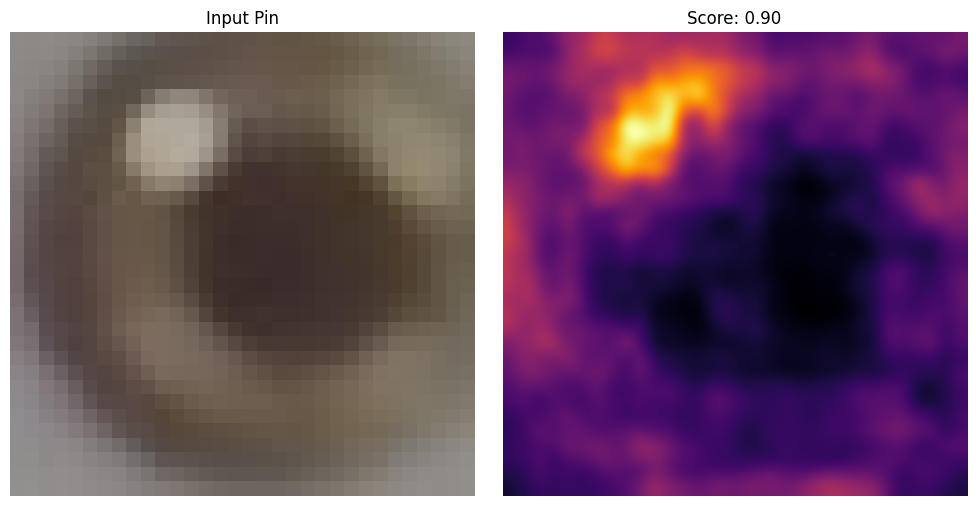

In [2]:
def inspect_pin(model_path, pin_image_path):
    inferencer = TorchInferencer(path=model_path, device="cpu")
    predictions = inferencer.predict(image=pin_image_path)
    
    # --- HANDLE HEATMAP SHAPE ---
    anom_map = predictions.anomaly_map
    if hasattr(anom_map, "cpu"): 
        anom_map = anom_map.cpu().numpy()
    anom_map = anom_map.squeeze() # Removes (1, 256, 256) -> (256, 256)

    # --- HANDLE SCORE FORMATTING ---
    # Convert Tensor to float using .item()
    score = predictions.pred_score.item() 

    # Visualize
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    
    # Original Image
    ax[0].imshow(cv2.cvtColor(cv2.imread(pin_image_path), cv2.COLOR_BGR2RGB))
    ax[0].set_title("Input Pin")
    ax[0].axis('off')
    
    # Anomaly Heatmap
    ax[1].imshow(anom_map, cmap='inferno') 
    ax[1].set_title(f"Score: {score:.2f}") # Now valid because 'score' is a float
    ax[1].axis('off')
    
    plt.tight_layout()
    plt.show()

img_path = "./datasets/socket_pins/test/defect/"
for img in os.listdir(img_path):
    inspect_pin("./results/Padim/socket_pins/latest/weights/torch/model.pt", f"{img_path}{img}")

In [3]:
import fiftyone as fo 
import fiftyone.brain as fob # ML methods
import fiftyone.zoo as foz # zoo datasets and models
from fiftyone import ViewField as F # helper for defining views

OBJECT="socket_pin"

# Initialize Dataset
if "socket_dataset" in fo.list_datasets():
    fo.delete_dataset("socket_dataset")
dataset = fo.Dataset("socket_dataset")

samples = []
data_path = "./datasets/socket_pins"

train_dir = os.path.join(data_path, "train", "good")
if os.path.exists(train_dir):
    for file in os.listdir(train_dir):
        if file.lower().endswith(('.jpg', '.png')):
            sample = fo.Sample(filepath=os.path.join(train_dir, file))
            
            sample["split"] = "train"
            sample["category"] = fo.Classification(label=OBJECT)
            sample["state"] = fo.Classification(label="good")
            
            samples.append(sample)

test_good_dir = os.path.join(data_path, "test", "good")
if os.path.exists(test_good_dir):
    for file in os.listdir(test_good_dir):
        if file.lower().endswith(('.jpg', '.png')):
            sample = fo.Sample(filepath=os.path.join(test_good_dir, file))
            
            sample["split"] = "test"
            sample["category"] = fo.Classification(label=OBJECT)
            sample["state"] = fo.Classification(label="good")
            
            samples.append(sample)

dataset.add_samples(samples)
print(f"Loaded {len(samples)} samples.")

 100% |███████████████| 2125/2125 [1.1s elapsed, 0s remaining, 2.0K samples/s]         
Loaded 2125 samples.


In [4]:
""" model = foz.load_zoo_model("clip-vit-base32-torch") """
model = foz.load_zoo_model("resnet50-imagenet-torch")

# Compute embeddings for the dataset
""" dataset.compute_embeddings(model=model, embeddings_field="clip_embeddings", batch_size=64) """
dataset.compute_embeddings(model=model, embeddings_field="resnet50_embeddings", batch_size=64)


# Dimensionality reduction using UMAP on the embeddings
fob.compute_visualization(dataset, embeddings="resnet50_embeddings", method="umap", brain_key="clip_vis")

Model does not support batching
 100% |███████████████| 2125/2125 [57.3m elapsed, 0s remaining, 3.4 samples/s]      
Generating visualization...
UMAP( verbose=True)
Thu Dec 25 15:30:12 2025 Construct fuzzy simplicial set
Thu Dec 25 15:30:25 2025 Finding Nearest Neighbors
Thu Dec 25 15:30:38 2025 Finished Nearest Neighbor Search
Thu Dec 25 15:30:44 2025 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Thu Dec 25 15:30:50 2025 Finished embedding


In [5]:
from sklearn.cluster import KMeans, HDBSCAN
import numpy as np

# Extract the embeddings from the dataset
embeddings = np.array(dataset.values("resnet50_embeddings"))

# KMeans clustering
num_clusters = 3 # 3 cluster
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(embeddings)

# Add the cluster IDs back to the dataset as a new field
dataset.set_values("cluster_id", [str(c) for c in clusters])

print(f"Assigned {len(clusters)} samples to {num_clusters} clusters.")

Assigned 2125 samples to 3 clusters.


In [6]:
cluster_1_view = dataset.match(F("cluster_id") == "1")
for sample in cluster_1_view:
    sample["state"].label = "hole"
    sample.save() 

cluster_2_view = dataset.match(F("cluster_id") == "0")
for sample in cluster_2_view:
    sample["state"].label = "????"
    sample.save()

cluster_3_view = dataset.match(F("cluster_id") == "2")
for sample in cluster_3_view:
    sample["state"].label = "pin"
    sample.save()

In [8]:
session = fo.launch_app(dataset)